# Logistic-regression random-label selectivity

This Colab notebook runs **logistic_regression** on ToyMovieReview and full AIT using
last-non-padding-token residual activations. It has separate GPT-2 Small and
Qwen3-0.6B Base sections, but both write beneath one shared Google Drive run ID.

Three explicit logistic-regression trials are compared on real validation balanced accuracy. The selected C, penalty, and class weight are then frozen.

Every random-label seed is paired with a real-task run using the same optimization
seed. Labels are permuted independently within train, validation, and test while
preserving each split's class counts. Hyperparameters are selected on the real
validation split only; test data never affects selection. Each model section first
finishes tuning, displays the trial table and tuning plot, and freezes the selection.
Paired real/random training starts in a separate cell. Final result tables are written
only after both paired tasks finish. Combined plots are created only when all four
methods and both models are present.

## 1. Settings

Keep the same `RUN_ID` in all four notebooks. Change it before starting a new study.
The configured fixed residual boundaries are:

| Dataset | GPT-2 Small | Qwen3-0.6B Base |
|---|---:|---:|
| ToyMovieReview | 10 | 26 |
| Full AIT | 11 | 26 |

In [1]:
PROJECT_URL = "https://github.com/Adefioye/sentiment-manifold.git"
PROJECT_REVISION = None  # Optional immutable commit or tag.
DRIVE_ROOT = "/content/drive/MyDrive/sentiment-geometry/selectivity"
RUN_ID = "fixed-layer-selectivity-v1"  # Use this exact value in all four notebooks.

METHOD = "logistic_regression"
DEVICE = "cuda"
DTYPE = "auto"
RUN_TUNING = True
RUN_FINAL_TRAINING = True
SHOW_PROGRESS = True
HF_TOKEN_SOURCE = "prompt"  # "prompt" (hidden entry) or "colab_secret".

MANUAL_TRIALS = [
    {"c": 0.1, "penalty": "l2", "class_weight": None},
    {"c": 1.0, "penalty": "l2", "class_weight": None},
    {"c": 10.0, "penalty": "l2", "class_weight": None},
]

## 2. Install the package, verify imports, and mount Drive

The notebook imports the editable checkout, verifies its filesystem location, imports
every package module, and checks the public APIs used below. This catches stale Colab
modules before a long run starts. The notebook calls package APIs rather than
reimplementing extraction, fitting, randomization, evaluation, or persistence.

In [2]:
import importlib
import os
import pkgutil
import subprocess
import sys
from pathlib import Path

from google.colab import drive

PROJECT_ROOT = Path("/content/sentiment-manifold")
if not (PROJECT_ROOT / ".git").is_dir():
    subprocess.run(["git", "clone", PROJECT_URL, str(PROJECT_ROOT)], check=True)
if PROJECT_REVISION is not None:
    subprocess.run(
        ["git", "checkout", "--detach", PROJECT_REVISION],
        cwd=PROJECT_ROOT,
        check=True,
    )
project_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True
).strip()
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", f"{PROJECT_ROOT}[notebooks]"],
    check=True,
)
os.chdir(PROJECT_ROOT)
root_string = str(PROJECT_ROOT.resolve())
if root_string in sys.path:
    sys.path.remove(root_string)
sys.path.insert(0, root_string)
for module_name in list(sys.modules):
    if module_name == "sentiment_geometry" or module_name.startswith("sentiment_geometry."):
        del sys.modules[module_name]
importlib.invalidate_caches()

sentiment_geometry = importlib.import_module("sentiment_geometry")
expected_package_root = (PROJECT_ROOT / "sentiment_geometry").resolve()
imported_package_root = Path(sentiment_geometry.__file__).resolve().parent
if imported_package_root != expected_package_root:
    raise ImportError(
        f"Imported sentiment_geometry from {imported_package_root}, "
        f"expected {expected_package_root}. Restart the runtime and rerun from the top."
    )
module_names = sorted(
    module.name
    for module in pkgutil.walk_packages(
        sentiment_geometry.__path__, prefix="sentiment_geometry."
    )
    if module.name != "sentiment_geometry.__main__"
)
for module_name in module_names:
    importlib.import_module(module_name)
required_apis = {
    "sentiment_geometry.experiments.selectivity": {
        "FixedLayerSelectivityConfig",
        "run_fixed_layer_selectivity_with_frozen_hyperparameters",
        "tune_fixed_layer_selectivity",
    },
    "sentiment_geometry.reporting": {
        "combine_fixed_layer_selectivity_runs",
        "load_fixed_layer_hyperparameter_selections",
        "load_fixed_layer_tuning_trials",
        "load_fixed_layer_selectivity_report",
        "plot_fixed_layer_selectivity",
        "plot_fixed_layer_hyperparameter_tuning",
        "plot_fixed_layer_run_diagnostics",
    },
}
for module_name, api_names in required_apis.items():
    module = importlib.import_module(module_name)
    missing_apis = sorted(name for name in api_names if not hasattr(module, name))
    if missing_apis:
        raise ImportError(f"{module_name} is missing {missing_apis}.")

drive.mount("/content/drive")
RUN_ROOT = Path(DRIVE_ROOT) / RUN_ID
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print("Project commit:", project_commit)
print("Imported package from:", imported_package_root)
print(f"Imported and checked {len(module_names)} package modules.")
print("Shared run root:", RUN_ROOT)

Mounted at /content/drive
Project commit: fa208c5488bb994c45b427de35d8c1d840a84e57
Imported package from: /content/sentiment-manifold/sentiment_geometry
Imported and checked 80 package modules.
Shared run root: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1


## 3. Authenticate to Hugging Face

The default `HF_TOKEN_SOURCE = "prompt"` asks for the token through a hidden manual
prompt, matching the earlier notebooks. To use Colab Secrets instead, add a secret
named `HF_TOKEN` and set `HF_TOKEN_SOURCE = "colab_secret"`. The token is kept only in
runtime memory, is never printed or written to Drive, and is placed in the environment
only while a model run is actively loading AIT data.

In [3]:
import gc
from getpass import getpass

from huggingface_hub import HfApi
from huggingface_hub.utils import reset_sessions

_RUNTIME_SECRETS = {}

def get_runtime_secret(name):
    if name in _RUNTIME_SECRETS:
        return _RUNTIME_SECRETS[name]
    if HF_TOKEN_SOURCE == "prompt":
        value = getpass(f"Enter {name} (input hidden): ").strip()
    elif HF_TOKEN_SOURCE == "colab_secret":
        from google.colab import userdata

        value = (userdata.get(name) or "").strip()
    else:
        raise ValueError("HF_TOKEN_SOURCE must be 'prompt' or 'colab_secret'.")
    if not value:
        raise RuntimeError(f"{name} was not provided.")
    _RUNTIME_SECRETS[name] = value
    return value

def release_hf_environment(env_name="HF_TOKEN"):
    os.environ.pop(env_name, None)
    reset_sessions()
    gc.collect()

def clear_hf_credentials(env_name="HF_TOKEN"):
    release_hf_environment(env_name)
    value = _RUNTIME_SECRETS.pop("HF_TOKEN", None)
    if value is not None:
        del value

_token = get_runtime_secret("HF_TOKEN")
try:
    hf_account = HfApi(token=_token).whoami()["name"]
except BaseException:
    clear_hf_credentials()
    raise
finally:
    del _token
print(
    f"Authenticated to Hugging Face as {hf_account}. "
    "Token value was not displayed."
)

Authenticated to Hugging Face as kokolamba. Token value was not displayed.


## 4. Verify the protocol and define the staged runners

A trial list contains complete hand-chosen configurations, not a grid. There are no
more than three user-adjusted hyperparameters for this method. The tuning runner stops
after validation-only selection and visualization. The final runner starts separately
and uses exactly the frozen settings shown between the two stages.

In [4]:
import pandas as pd
from IPython.display import Image, display

from sentiment_geometry.experiments.selectivity import (
    FixedLayerSelectivityConfig,
    run_fixed_layer_selectivity_with_frozen_hyperparameters,
    tune_fixed_layer_selectivity,
)
from sentiment_geometry.reporting import (
    combine_fixed_layer_selectivity_runs,
    load_fixed_layer_hyperparameter_selections,
    load_fixed_layer_tuning_trials,
    load_fixed_layer_selectivity_report,
    plot_fixed_layer_selectivity,
    plot_fixed_layer_hyperparameter_tuning,
    plot_fixed_layer_run_diagnostics,
)

CONFIG_PATH = PROJECT_ROOT / "configs/selectivity/fixed_layer.yaml"
EXPECTED_LAYERS = {
    "gpt2-small": {"toy_movie_review": 10, "full_ait": 11},
    "qwen-0.6b": {"toy_movie_review": 26, "full_ait": 26},
}

def display_table(title, frame, columns=None):
    print(title)
    selected = frame
    if columns is not None:
        selected = frame[[column for column in columns if column in frame.columns]]
    display(selected.round(4))

def configured_run(model_name):
    config = FixedLayerSelectivityConfig.load(CONFIG_PATH)
    config.models = [model for model in config.models if model.name == model_name]
    if len(config.models) != 1:
        raise ValueError(f"Expected exactly one config for {model_name}")
    model = config.models[0]
    model.device = DEVICE
    model.dtype = DTYPE
    actual_layers = {
        dataset: model.layer_for(dataset) for dataset in config.data.datasets
    }
    if actual_layers != EXPECTED_LAYERS[model_name]:
        raise ValueError(
            f"Layer contract changed for {model_name}: {actual_layers}"
        )
    config.methods = [METHOD]
    config.output.output_dir = str(RUN_ROOT / "methods" / METHOD)
    config.output.run_id = model_name
    config.progress.enabled = SHOW_PROGRESS
    config.logistic_regression.trials = list(MANUAL_TRIALS)
    config.validate(require_layers=True)
    return config

def tuning_and_display(model_name):
    config = configured_run(model_name)
    run_dir = Path(config.output.output_dir) / config.output.run_id
    if RUN_TUNING:
        token_env = config.data.hf_token_env
        os.environ[token_env] = get_runtime_secret("HF_TOKEN")
        try:
            run_dir = tune_fixed_layer_selectivity(config)
        finally:
            release_hf_environment(token_env)
    selections = load_fixed_layer_hyperparameter_selections(run_dir)
    try:
        trials = load_fixed_layer_tuning_trials(run_dir)
    except FileNotFoundError:
        print("This method has no hyperparameter trials to compare.")
    else:
        display_table(
            "Real-validation tuning trials (selected rows are marked):",
            trials,
            [
                "dataset", "layer", "trial_index", "hyperparameters",
                "validation_native_accuracy",
                "validation_native_balanced_accuracy",
                "validation_midpoint_balanced_accuracy",
                "validation_loss", "validation_recovery",
                "validation_logit_flip", "validation_sign_flip", "selected",
            ],
        )
        tuning_figure = plot_fixed_layer_hyperparameter_tuning(run_dir)
        print("Validation-only tuning plot:", tuning_figure)
        display(Image(filename=str(tuning_figure)))
    print("Frozen settings (inspect before starting final training):")
    display(pd.json_normalize(selections, sep=" → ").T.rename(columns={0: "value"}))
    return run_dir, selections

def final_training_and_display(model_name, selections):
    config = configured_run(model_name)
    run_dir = Path(config.output.output_dir) / config.output.run_id
    if RUN_FINAL_TRAINING:
        token_env = config.data.hf_token_env
        os.environ[token_env] = get_runtime_secret("HF_TOKEN")
        try:
            run_dir = run_fixed_layer_selectivity_with_frozen_hyperparameters(
                config, selections
            )
        finally:
            release_hf_environment(token_env)
    if not (run_dir / "metrics.csv").is_file():
        raise FileNotFoundError(f"No completed final results at {run_dir}")

    report = load_fixed_layer_selectivity_report(run_dir)

    metric_columns = [
        "model", "dataset", "layer", "task", "split", "n_seeds",
        "native_balanced_accuracy_mean", "native_balanced_accuracy_std",
        "midpoint_balanced_accuracy_mean", "midpoint_balanced_accuracy_std",
        "prediction_agreement_mean",
    ]
    display_table(
        "Training memorization diagnostic (real and random labels):",
        report.training_memorization,
        metric_columns,
    )
    display_table(
        "All-split performance, mean and standard deviation across paired seeds:",
        report.performance,
        metric_columns,
    )
    display_table(
        "Native versus midpoint gaps and prediction agreement:",
        report.native_midpoint_comparison,
        [
            "model", "dataset", "layer", "task", "split", "n_seeds",
            "accuracy_gap_midpoint_minus_native_mean",
            "balanced_gap_midpoint_minus_native_mean",
            "prediction_agreement_mean",
        ],
    )
    balanced_selectivity = report.selectivity[
        report.selectivity["metric"].isin(
            ["native_balanced_accuracy", "midpoint_balanced_accuracy"]
        )
    ]
    display_table(
        "Paired selectivity, including train, validation, and test:",
        balanced_selectivity,
        [
            "model", "dataset", "layer", "split", "metric",
            "selectivity_mean", "selectivity_std", "selectivity_ci95_low",
            "selectivity_ci95_high", "n_seeds",
        ],
    )
    display_table(
        "Fit diagnostics and selected training epochs:",
        report.fit_diagnostics,
        [
            "model", "dataset", "layer", "task", "seed", "hyperparameters",
            "n_parameters", "best_epoch", "epochs_completed_from_history",
            "best_validation_loss", "best_training_loss",
        ],
    )
    if not report.das_causal_metrics.empty:
        display_table(
            "DAS IIA, patched/clean/corrupted accuracy, recovery, "
            "logit flip, and sign flip:",
            report.das_causal_metrics,
            [
                "model", "dataset", "layer", "task", "split", "n_seeds",
                "iia_mean", "iia_std", "patched_accuracy_mean",
                "clean_accuracy_mean", "corrupted_accuracy_mean",
                "recovery_mean", "recovery_std", "logit_flip_mean",
                "logit_flip_std", "sign_flip_rate_mean",
                "sign_flip_rate_std",
            ],
        )

    print("Per-model diagnostic plots:")
    for figure in plot_fixed_layer_run_diagnostics(run_dir):
        print(" -", figure)
        display(Image(filename=str(figure)))
    return run_dir

## 5. GPT-2 Small

### 5a. Tune on real validation data and visualize every trial

This stage does not train either final real-label or random-label model.

Selectivity tuning models:   0%|          | 0/1 [00:00<?, ?model/s]

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

gpt2-small full_ait test activations:   0%|          | 0/35 [00:00<?, ?batch/s]

gpt2-small full_ait tune:   0%|          | 0/1 [00:00<?, ?method/s]

Real-validation tuning trials (selected rows are marked):


,dataset,layer,trial_index,hyperparameters,validation_native_accuracy,validation_native_balanced_accuracy,validation_midpoint_balanced_accuracy,validation_loss,selected
0,toy_movie_review,10,0,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1.0000,1.0000,1.0000,NaN,True
1,toy_movie_review,10,1,"{""c"": 1.0, ""class_weight"": null, ""max_iter"": 5...",1.0000,1.0000,1.0000,NaN,False
2,toy_movie_review,10,2,"{""c"": 10.0, ""class_weight"": null, ""max_iter"": ...",1.0000,1.0000,1.0000,NaN,False
3,full_ait,11,0,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",0.8788,0.8788,0.8737,NaN,True
4,full_ait,11,1,"{""c"": 1.0, ""class_weight"": null, ""max_iter"": 5...",0.8788,0.8788,0.8788,NaN,False
5,full_ait,11,2,"{""c"": 10.0, ""class_weight"": null, ""max_iter"": ...",0.8788,0.8788,0.8737,NaN,False


Validation-only tuning plot: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/gpt2-small/figures/hyperparameter_tuning.png


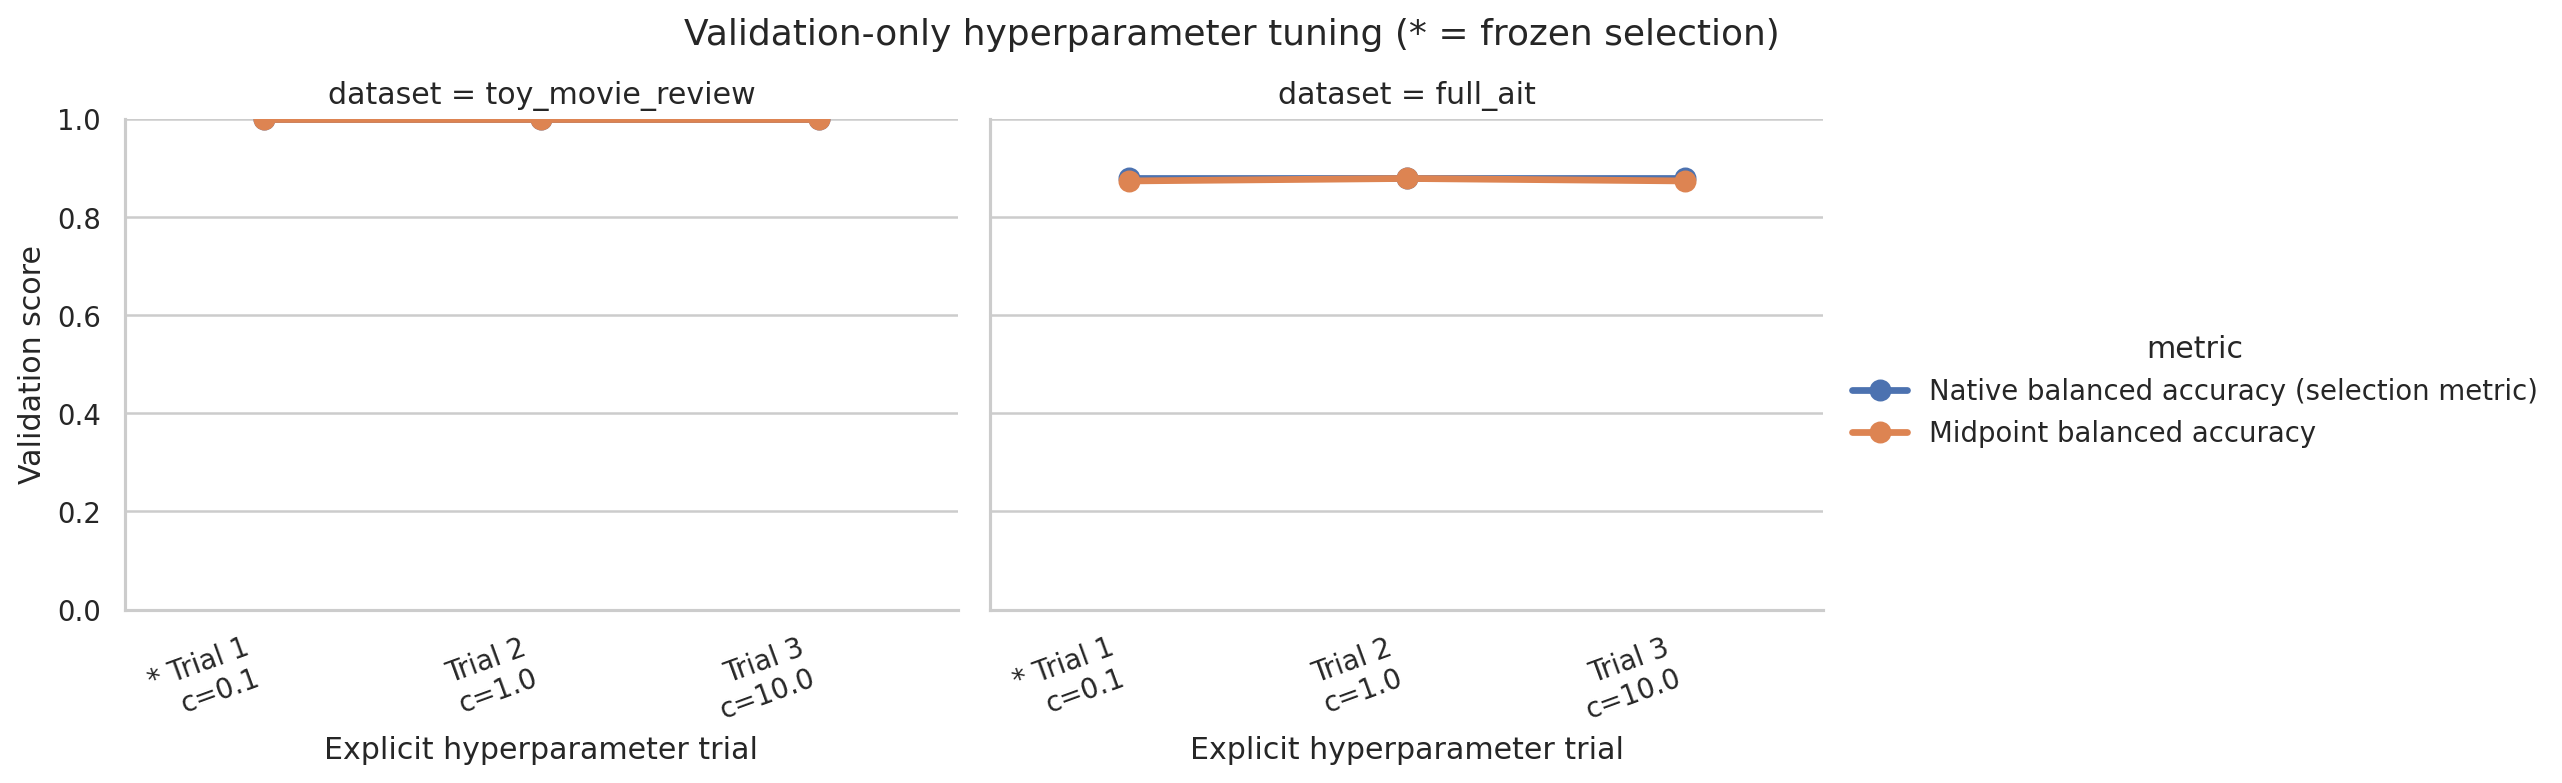

Frozen settings (inspect before starting final training):


,value
gpt2-small → full_ait → logistic_regression → c,0.1
gpt2-small → full_ait → logistic_regression → class_weight,None
gpt2-small → full_ait → logistic_regression → max_iter,5000
gpt2-small → full_ait → logistic_regression → penalty,l2
gpt2-small → full_ait → logistic_regression → solver,liblinear
gpt2-small → full_ait → logistic_regression → tol,0.0001
gpt2-small → toy_movie_review → logistic_regression → c,0.1
gpt2-small → toy_movie_review → logistic_regression → class_weight,None
gpt2-small → toy_movie_review → logistic_regression → max_iter,5000
gpt2-small → toy_movie_review → logistic_regression → penalty,l2


GPT-2 tuning artifacts: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/gpt2-small


In [5]:
GPT2_TUNING_DIR, GPT2_SELECTIONS = tuning_and_display("gpt2-small")
print("GPT-2 tuning artifacts:", GPT2_TUNING_DIR)

### 5b. Inspect or deliberately override the frozen GPT-2 settings

The automatically selected values are already frozen in `GPT2_SELECTIONS`. If you
deliberately override one, edit the nested dictionary here before running 5c and
document the reason. Do not consult test performance when making that decision.

In [6]:
# Example only (leave commented for validation-selected settings):
# GPT2_SELECTIONS["gpt2-small"]["toy_movie_review"][METHOD]["c"] = 1.0
display(pd.json_normalize(GPT2_SELECTIONS, sep=" → ").T.rename(columns={0: "value"}))

,value
gpt2-small → full_ait → logistic_regression → c,0.1
gpt2-small → full_ait → logistic_regression → class_weight,None
gpt2-small → full_ait → logistic_regression → max_iter,5000
gpt2-small → full_ait → logistic_regression → penalty,l2
gpt2-small → full_ait → logistic_regression → solver,liblinear
gpt2-small → full_ait → logistic_regression → tol,0.0001
gpt2-small → toy_movie_review → logistic_regression → c,0.1
gpt2-small → toy_movie_review → logistic_regression → class_weight,None
gpt2-small → toy_movie_review → logistic_regression → max_iter,5000
gpt2-small → toy_movie_review → logistic_regression → penalty,l2


### 5c. Train paired real/random-label tasks with the frozen GPT-2 settings

Final metrics and diagnostic plots appear only after every paired seed finishes.

Selectivity final models:   0%|          | 0/1 [00:00<?, ?model/s]

gpt2-small final datasets:   0%|          | 0/2 [00:00<?, ?dataset/s]

gpt2-small toy_movie_review final paired seeds:   0%|          | 0/5 [00:00<?, ?seed/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Paired selectivity, including train, validation, and test:


,model,dataset,layer,split,metric,selectivity_mean,selectivity_std,selectivity_ci95_low,selectivity_ci95_high,n_seeds
6,gpt2-small,full_ait,11,test,native_balanced_accuracy,0.3663,0.0361,0.3346,0.3980,5
7,gpt2-small,full_ait,11,train,native_balanced_accuracy,0.0536,0.0110,0.0439,0.0633,5
8,gpt2-small,full_ait,11,validation,native_balanced_accuracy,0.3758,0.0408,0.3400,0.4115,5
9,gpt2-small,toy_movie_review,10,test,native_balanced_accuracy,0.5009,0.0444,0.4620,0.5398,5
10,gpt2-small,toy_movie_review,10,train,native_balanced_accuracy,0.0158,0.0144,0.0032,0.0284,5
11,gpt2-small,toy_movie_review,10,validation,native_balanced_accuracy,0.4667,0.1830,0.3063,0.6270,5
18,gpt2-small,full_ait,11,test,midpoint_balanced_accuracy,0.3711,0.0358,0.3397,0.4024,5
19,gpt2-small,full_ait,11,train,midpoint_balanced_accuracy,0.0508,0.0102,0.0418,0.0597,5
20,gpt2-small,full_ait,11,validation,midpoint_balanced_accuracy,0.3717,0.0420,0.3349,0.4086,5
21,gpt2-small,toy_movie_review,10,test,midpoint_balanced_accuracy,0.4786,0.0439,0.4401,0.5171,5


Fit diagnostics and selected training epochs:


,model,dataset,layer,task,seed,hyperparameters,n_parameters,best_epoch,best_validation_loss,best_training_loss
0,gpt2-small,toy_movie_review,10,real,11,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
1,gpt2-small,toy_movie_review,10,random,11,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
2,gpt2-small,toy_movie_review,10,real,22,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
3,gpt2-small,toy_movie_review,10,random,22,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
4,gpt2-small,toy_movie_review,10,real,33,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
5,gpt2-small,toy_movie_review,10,random,33,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
6,gpt2-small,toy_movie_review,10,real,44,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
7,gpt2-small,toy_movie_review,10,random,44,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
8,gpt2-small,toy_movie_review,10,real,55,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None
9,gpt2-small,toy_movie_review,10,random,55,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",769,None,None,None


Per-model diagnostic plots:
 - /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/gpt2-small/figures/run_real_vs_random_accuracy.png


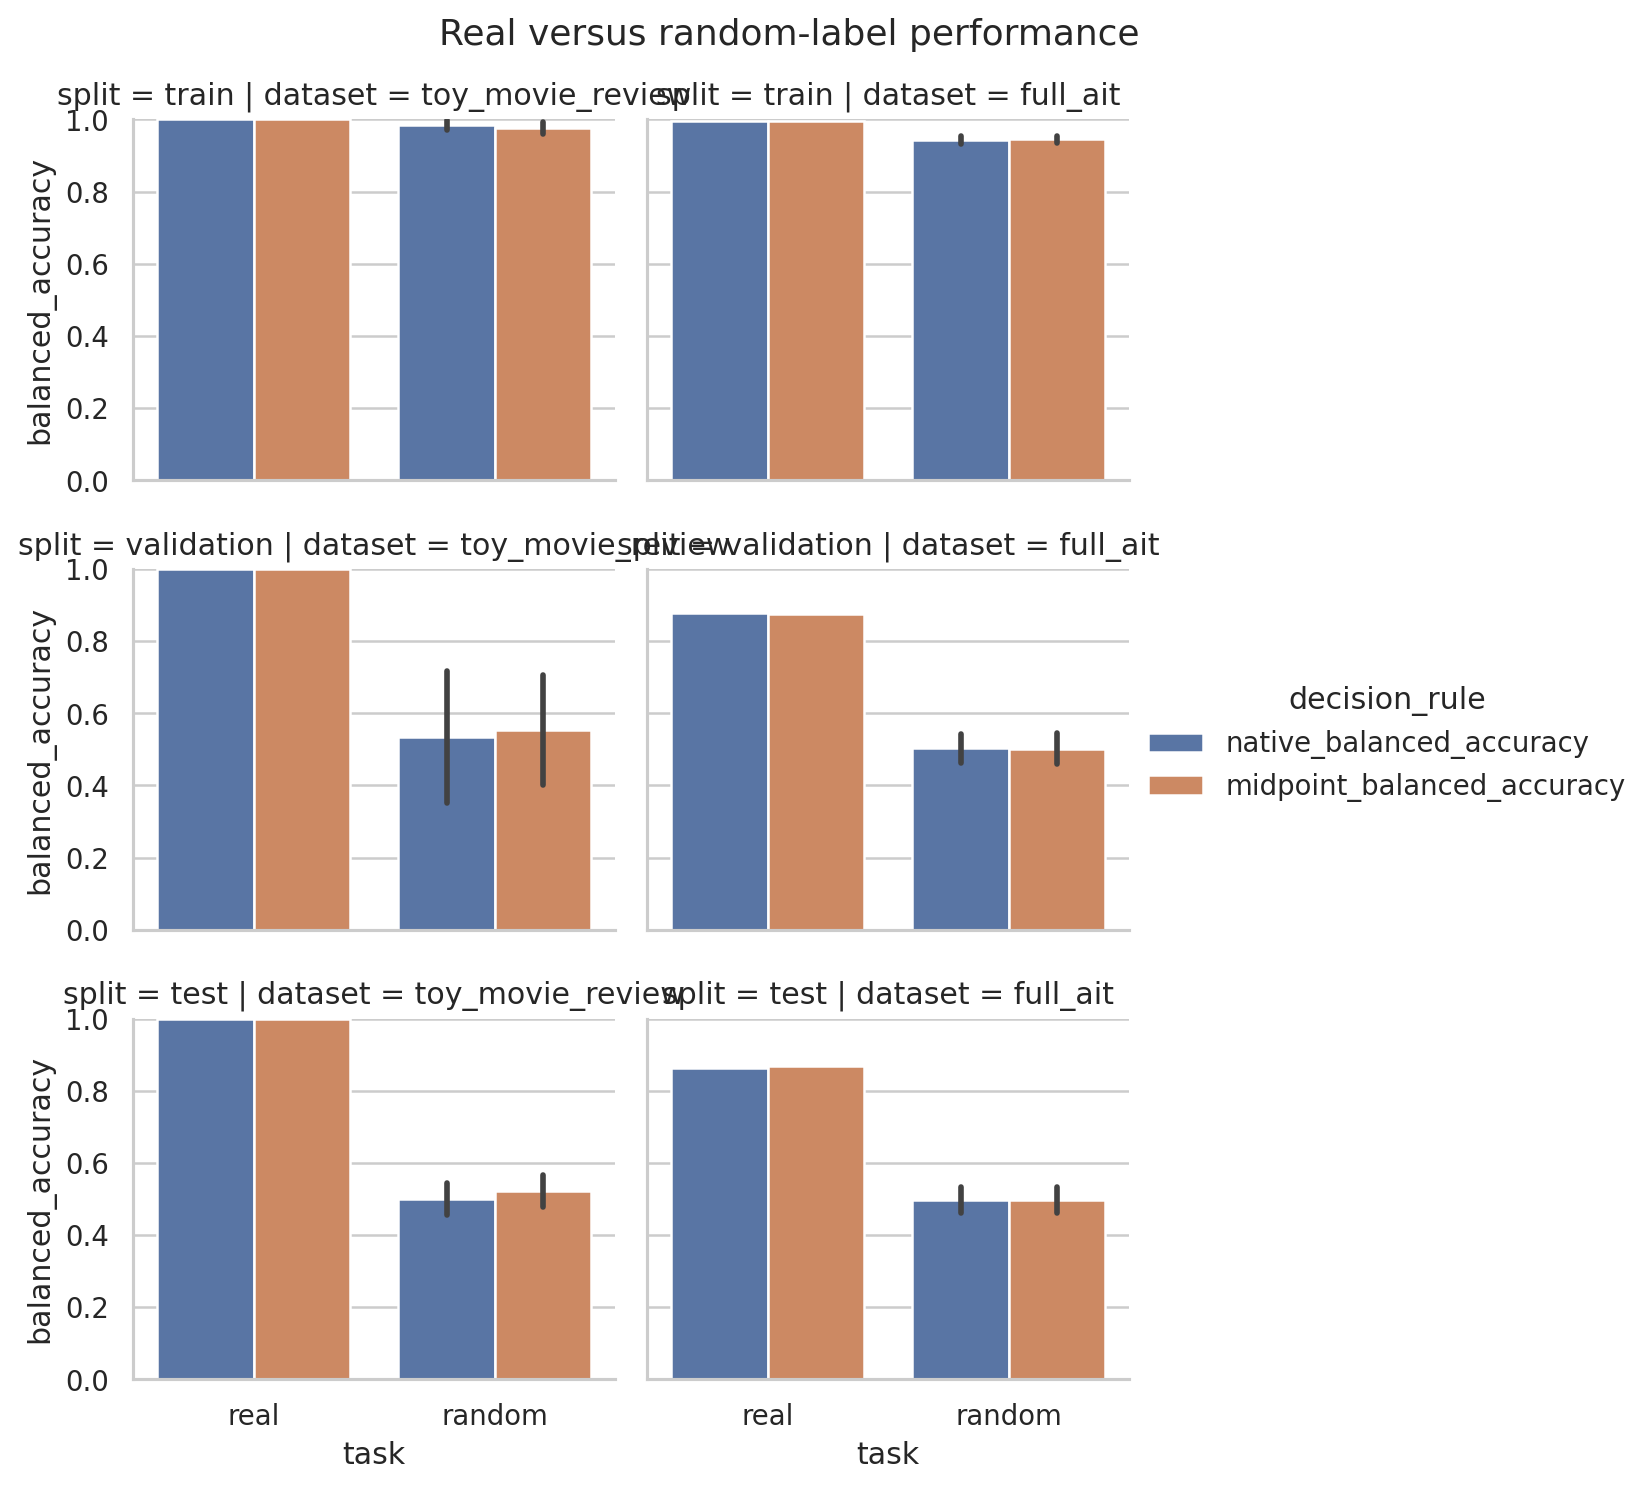

 - /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/gpt2-small/figures/run_selectivity.png


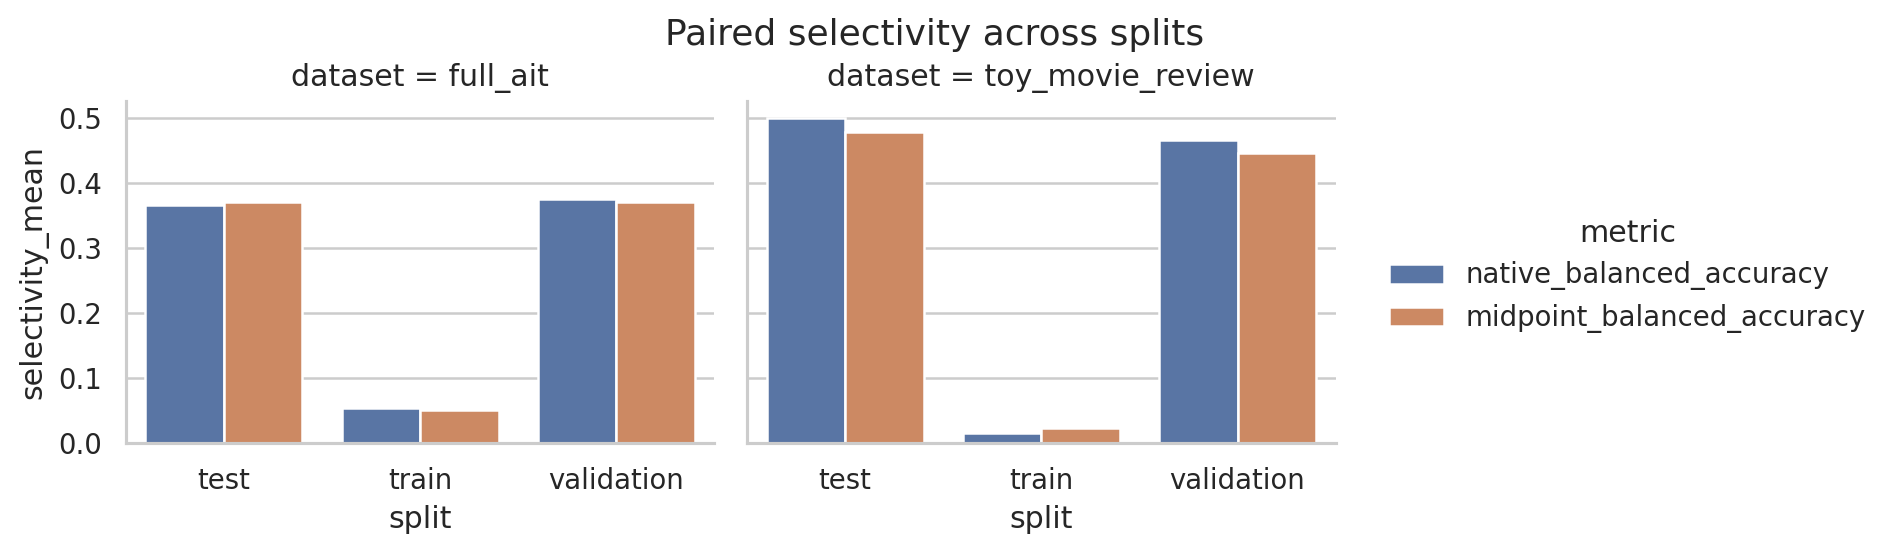

GPT-2 final artifacts: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/gpt2-small


In [7]:
GPT2_RUN_DIR = final_training_and_display("gpt2-small", GPT2_SELECTIONS)
print("GPT-2 final artifacts:", GPT2_RUN_DIR)

## 6. Qwen3-0.6B Base

### 6a. Tune on real validation data and visualize every trial

This repeats the complete selection process independently for Qwen and both datasets.

Selectivity tuning models:   0%|          | 0/1 [00:00<?, ?model/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

qwen-0.6b full_ait test activations:   0%|          | 0/69 [00:00<?, ?batch/s]

qwen-0.6b full_ait tune:   0%|          | 0/1 [00:00<?, ?method/s]

Real-validation tuning trials (selected rows are marked):


,dataset,layer,trial_index,hyperparameters,validation_native_accuracy,validation_native_balanced_accuracy,validation_midpoint_balanced_accuracy,validation_loss,selected
0,toy_movie_review,26,0,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1.0000,1.0000,1.0000,NaN,True
1,toy_movie_review,26,1,"{""c"": 1.0, ""class_weight"": null, ""max_iter"": 5...",1.0000,1.0000,1.0000,NaN,False
2,toy_movie_review,26,2,"{""c"": 10.0, ""class_weight"": null, ""max_iter"": ...",1.0000,1.0000,1.0000,NaN,False
3,full_ait,26,0,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",0.9364,0.9364,0.9364,NaN,True
4,full_ait,26,1,"{""c"": 1.0, ""class_weight"": null, ""max_iter"": 5...",0.9195,0.9195,0.9280,NaN,False
5,full_ait,26,2,"{""c"": 10.0, ""class_weight"": null, ""max_iter"": ...",0.9195,0.9195,0.9237,NaN,False


Validation-only tuning plot: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/qwen-0.6b/figures/hyperparameter_tuning.png


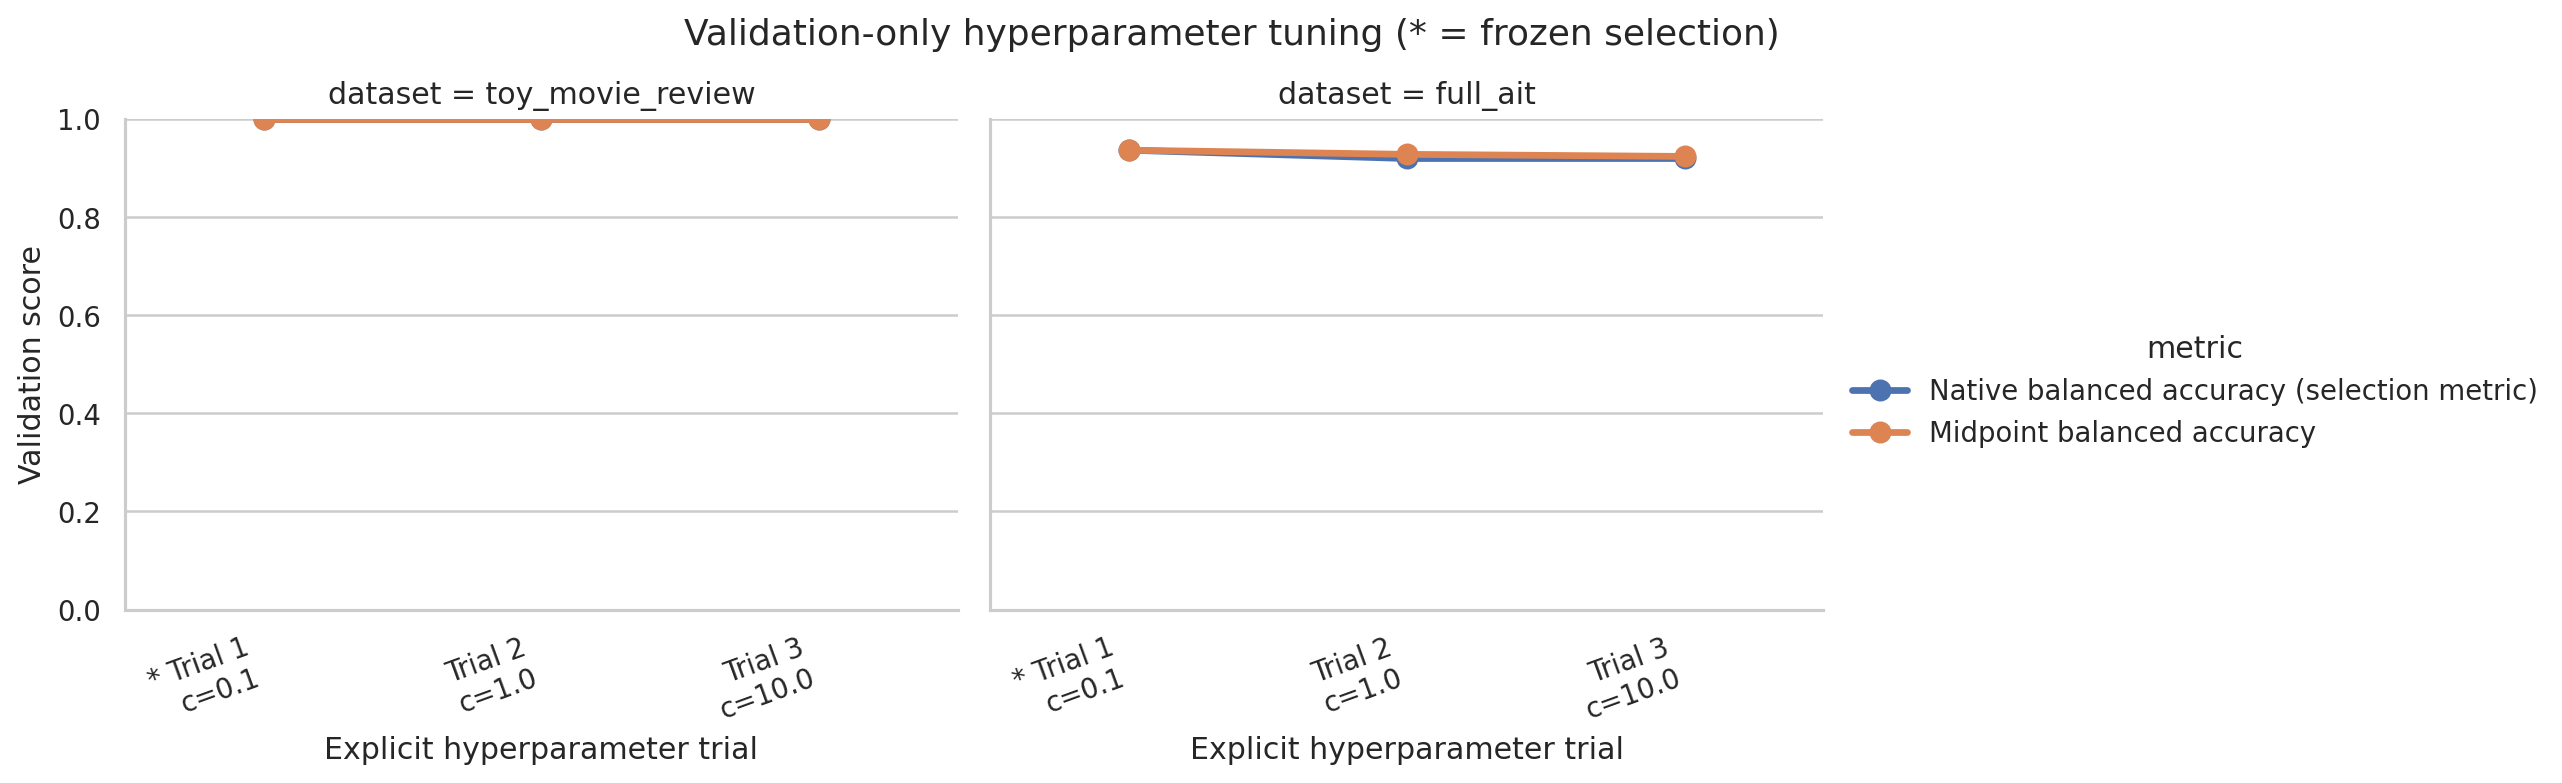

Frozen settings (inspect before starting final training):


,value
qwen-0.6b → full_ait → logistic_regression → c,0.1
qwen-0.6b → full_ait → logistic_regression → class_weight,None
qwen-0.6b → full_ait → logistic_regression → max_iter,5000
qwen-0.6b → full_ait → logistic_regression → penalty,l2
qwen-0.6b → full_ait → logistic_regression → solver,liblinear
qwen-0.6b → full_ait → logistic_regression → tol,0.0001
qwen-0.6b → toy_movie_review → logistic_regression → c,0.1
qwen-0.6b → toy_movie_review → logistic_regression → class_weight,None
qwen-0.6b → toy_movie_review → logistic_regression → max_iter,5000
qwen-0.6b → toy_movie_review → logistic_regression → penalty,l2


Qwen tuning artifacts: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/qwen-0.6b


In [8]:
QWEN_TUNING_DIR, QWEN_SELECTIONS = tuning_and_display("qwen-0.6b")
print("Qwen tuning artifacts:", QWEN_TUNING_DIR)

### 6b. Inspect or deliberately override the frozen Qwen settings

Leave the dictionary unchanged for the automatic validation-selected workflow.

In [9]:
# Example only (leave commented for validation-selected settings):
# QWEN_SELECTIONS["qwen-0.6b"]["toy_movie_review"][METHOD]["c"] = 1.0
display(pd.json_normalize(QWEN_SELECTIONS, sep=" → ").T.rename(columns={0: "value"}))

,value
qwen-0.6b → full_ait → logistic_regression → c,0.1
qwen-0.6b → full_ait → logistic_regression → class_weight,None
qwen-0.6b → full_ait → logistic_regression → max_iter,5000
qwen-0.6b → full_ait → logistic_regression → penalty,l2
qwen-0.6b → full_ait → logistic_regression → solver,liblinear
qwen-0.6b → full_ait → logistic_regression → tol,0.0001
qwen-0.6b → toy_movie_review → logistic_regression → c,0.1
qwen-0.6b → toy_movie_review → logistic_regression → class_weight,None
qwen-0.6b → toy_movie_review → logistic_regression → max_iter,5000
qwen-0.6b → toy_movie_review → logistic_regression → penalty,l2


### 6c. Train paired real/random-label tasks with the frozen Qwen settings

Final metrics and diagnostic plots appear only after every paired seed finishes.

Selectivity final models:   0%|          | 0/1 [00:00<?, ?model/s]

qwen-0.6b final datasets:   0%|          | 0/2 [00:00<?, ?dataset/s]

qwen-0.6b toy_movie_review final paired seeds:   0%|          | 0/5 [00:00<?, ?seed/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Paired selectivity, including train, validation, and test:


,model,dataset,layer,split,metric,selectivity_mean,selectivity_std,selectivity_ci95_low,selectivity_ci95_high,n_seeds
6,qwen-0.6b,full_ait,26,test,native_balanced_accuracy,0.3938,0.0215,0.3750,0.4126,5
7,qwen-0.6b,full_ait,26,train,native_balanced_accuracy,0.0000,0.0000,0.0000,0.0000,5
8,qwen-0.6b,full_ait,26,validation,native_balanced_accuracy,0.4398,0.0215,0.4210,0.4587,5
9,qwen-0.6b,toy_movie_review,26,test,native_balanced_accuracy,0.4500,0.0680,0.3904,0.5096,5
10,qwen-0.6b,toy_movie_review,26,train,native_balanced_accuracy,0.0000,0.0000,0.0000,0.0000,5
11,qwen-0.6b,toy_movie_review,26,validation,native_balanced_accuracy,0.5633,0.0996,0.4760,0.6506,5
18,qwen-0.6b,full_ait,26,test,midpoint_balanced_accuracy,0.3964,0.0209,0.3781,0.4146,5
19,qwen-0.6b,full_ait,26,train,midpoint_balanced_accuracy,0.0000,0.0000,0.0000,0.0000,5
20,qwen-0.6b,full_ait,26,validation,midpoint_balanced_accuracy,0.4390,0.0219,0.4198,0.4582,5
21,qwen-0.6b,toy_movie_review,26,test,midpoint_balanced_accuracy,0.4473,0.0829,0.3746,0.5200,5


Fit diagnostics and selected training epochs:


,model,dataset,layer,task,seed,hyperparameters,n_parameters,best_epoch,best_validation_loss,best_training_loss
0,qwen-0.6b,toy_movie_review,26,real,11,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
1,qwen-0.6b,toy_movie_review,26,random,11,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
2,qwen-0.6b,toy_movie_review,26,real,22,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
3,qwen-0.6b,toy_movie_review,26,random,22,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
4,qwen-0.6b,toy_movie_review,26,real,33,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
5,qwen-0.6b,toy_movie_review,26,random,33,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
6,qwen-0.6b,toy_movie_review,26,real,44,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
7,qwen-0.6b,toy_movie_review,26,random,44,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
8,qwen-0.6b,toy_movie_review,26,real,55,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None
9,qwen-0.6b,toy_movie_review,26,random,55,"{""c"": 0.1, ""class_weight"": null, ""max_iter"": 5...",1025,None,None,None


Per-model diagnostic plots:
 - /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/qwen-0.6b/figures/run_real_vs_random_accuracy.png


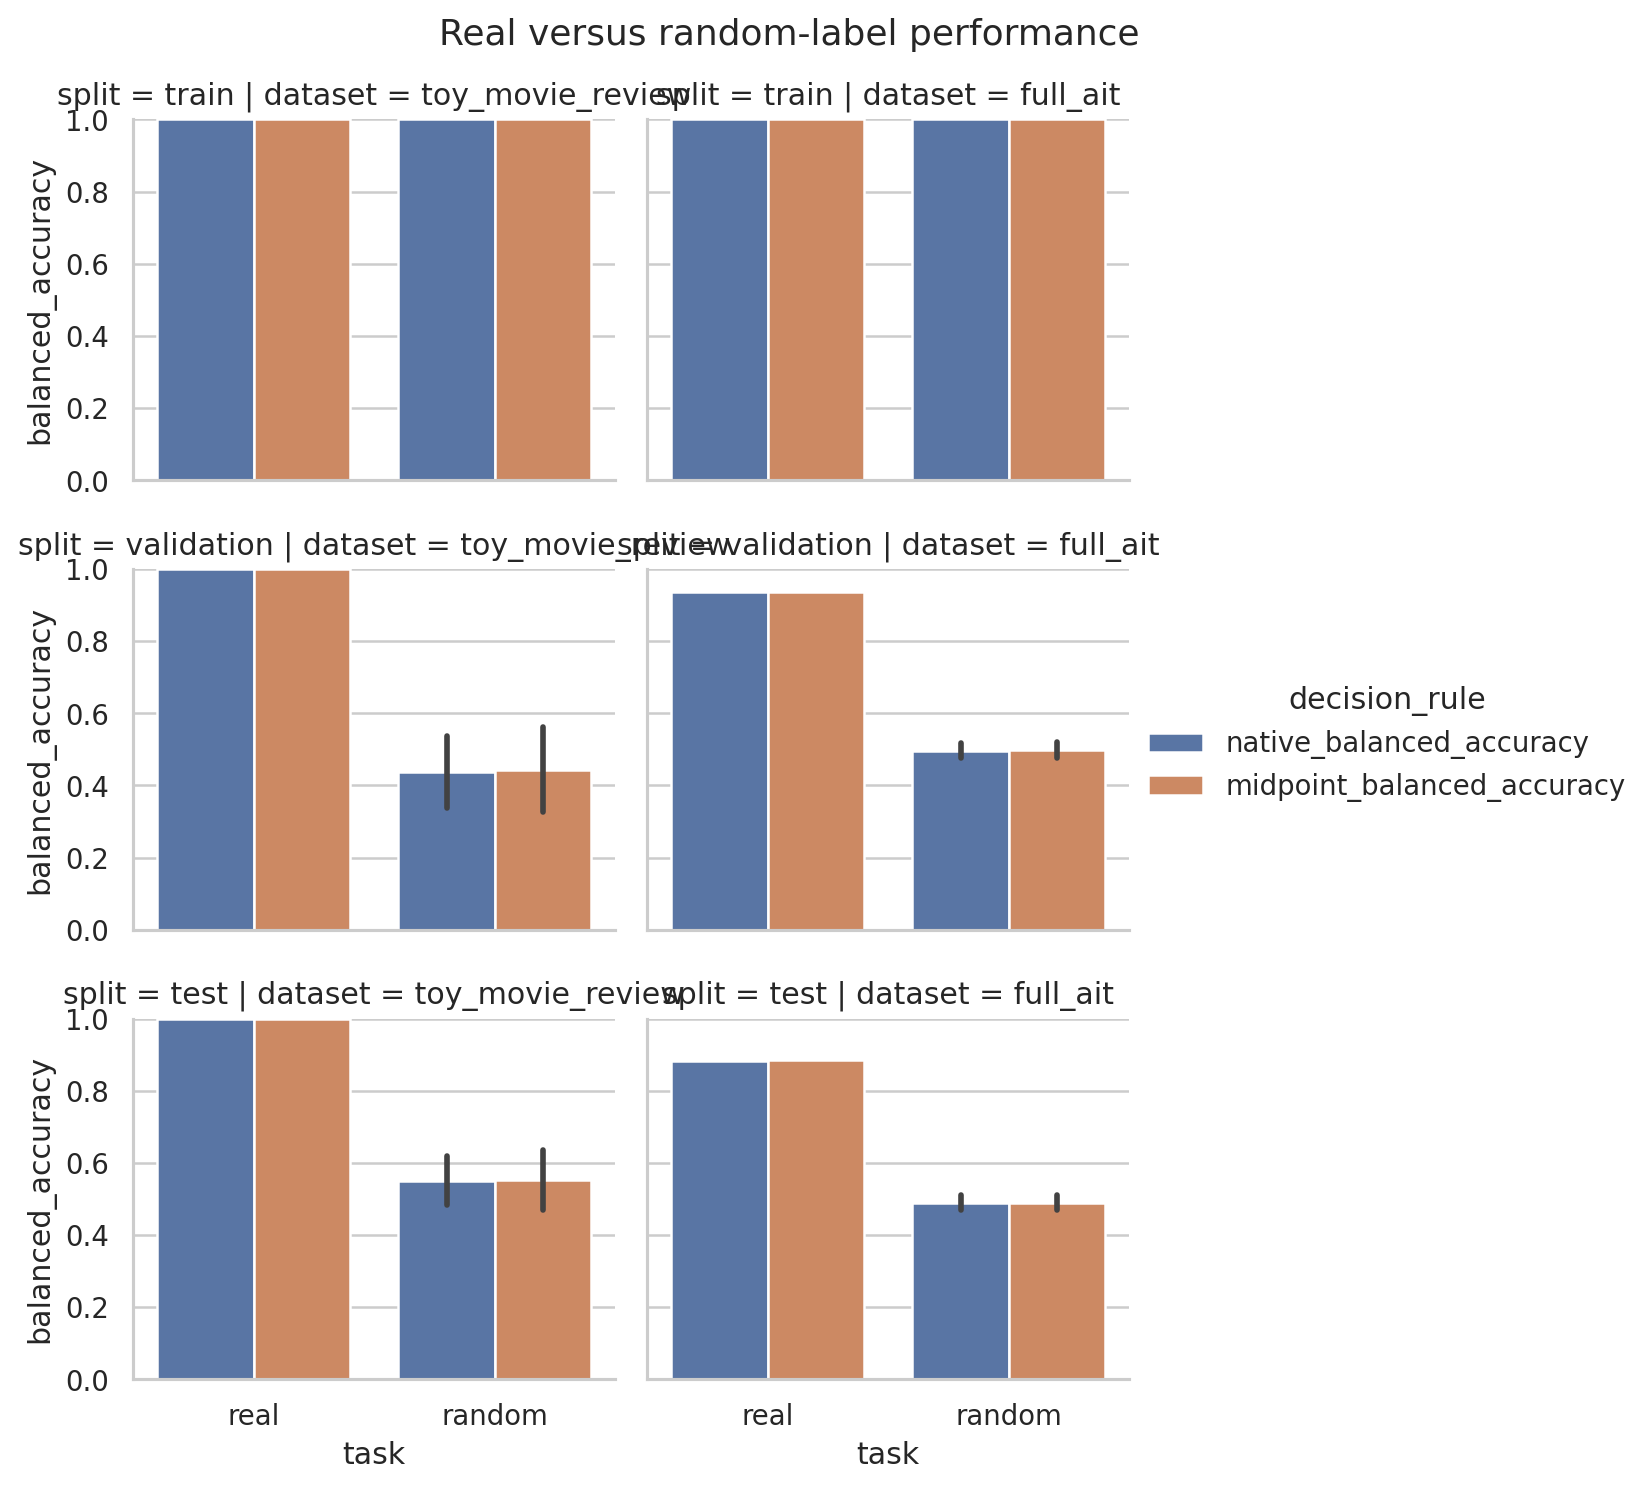

 - /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/qwen-0.6b/figures/run_selectivity.png


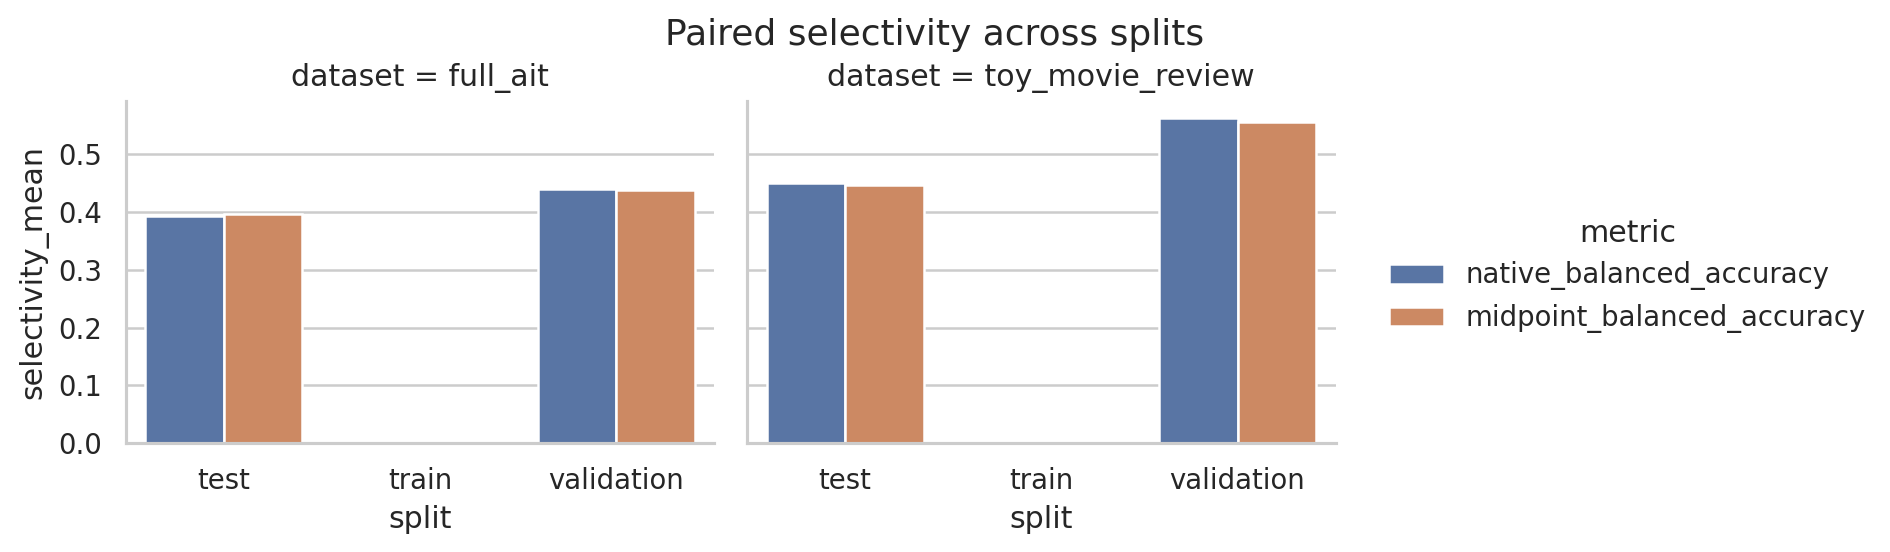

Qwen final artifacts: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/logistic_regression/qwen-0.6b


In [10]:
QWEN_RUN_DIR = final_training_and_display("qwen-0.6b", QWEN_SELECTIONS)
print("Qwen final artifacts:", QWEN_RUN_DIR)

## 7. Aggregate and plot only after every notebook is complete

This cell refuses to aggregate partial studies. Once all eight method/model folders
exist, it writes combined CSVs and the cross-method plots under `RUN_ROOT/combined`.
It is safe to rerun this cell after completing another method notebook.

In [11]:
try:
    COMBINED_DIR = combine_fixed_layer_selectivity_runs(RUN_ROOT)
except FileNotFoundError as error:
    print(error)
    print("No combined tables or plots were created from this partial study.")
else:
    FIGURES = plot_fixed_layer_selectivity(COMBINED_DIR)
    print("Combined tables:", COMBINED_DIR)
    print("Figures:")
    for figure in FIGURES:
        print(" -", figure)
        display(Image(filename=str(figure)))
    display(pd.read_csv(COMBINED_DIR / "selectivity_summary.csv"))
finally:
    clear_hf_credentials()
    if os.environ.get("HF_TOKEN") is not None:
        raise RuntimeError("HF_TOKEN remains in the notebook environment.")
    if "HF_TOKEN" in _RUNTIME_SECRETS:
        raise RuntimeError("HF_TOKEN remains in the runtime secret cache.")
    print("Verified: HF_TOKEN was cleared from runtime memory and the environment.")

All method/model runs must finish before aggregation. Missing: /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/das/gpt2-small, /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/das/qwen-0.6b, /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/mlp1/gpt2-small, /content/drive/MyDrive/sentiment-geometry/selectivity/fixed-layer-selectivity-v1/methods/mlp1/qwen-0.6b
No combined tables or plots were created from this partial study.
Verified: HF_TOKEN was cleared from runtime memory and the environment.
